# Download IG price history

**Producer** for `data/ig_market_data.db` and the first step in the pipeline
(`01` download → `02` import CSV → `03` view → `04` backtest). It pulls **OHLC
candles** for one IG market at one resolution over a chosen time window from
the IG REST API, then optionally persists them to a CSV and/or the shared
SQLite DB.

## Flow

| # | section | what happens |
| --- | --- | --- |
| — | **Setup** | editable-installs this repo's `igmarket` package (walks up to the repo root for `pyproject.toml`) so `import igmarket…` works |
| 1 | **Config** | set `START` / `END` / `RESOLUTION`; load credentials, `EPIC`, and the save toggles from `.env` |
| 2 | **Download** | authenticate an `IGSession`, page `GET /prices/{epic}` over `[START, END]`, print the candle count, UTC range, and remaining historical-data allowance |
| 3 | **Persist** | `SAVE_CSV` → a new timestamped CSV; `SAVE_DB` → `INSERT OR IGNORE` upsert into the resolution's `candles_<suffix>` table |
| 4 | **Preview** | DataFrame built from the candles in memory (works even if nothing was saved): `tail(10)` / `describe()` + a close-mid chart with a high/low band |

## What a run produces

- **Setup** → `CompletedProcess(..., returncode=0)` (pip, quiet).
- **Config** → one block: `Loaded config from …/.env`, the masked account
  line, `EPIC=… RESOLUTION=…`, the resolved `window (UTC): <start> -> <end>`,
  and `SAVE_CSV=… SAVE_DB=…`.
- **Download** → `Authenticated OK`, then `<n> <RESOLUTION> candles for
  <EPIC>`, the UTC `range` covered, and `historical-data allowance: <left> /
  <total> remaining (resets in <s>s)`.
- **Persist** → for each output either `SAVE_… is False - skipping …` or a
  written-path / `+<n> new row(s) in `candles_<suffix>`` line.
- **Preview** → a `tail(10)` table and a `describe()` table (or `Download
  returned 0 … candles` for an empty window), then a close-mid line chart —
  or `nothing to plot` if the window held no candles.

Nothing is written to `data/` unless `IG_SAVE_CSV` / `IG_SAVE_DB` is `true`.

## The three parameters (top of the section-1 cell)

| var | meaning | notes |
| --- | --- | --- |
| `START` | window start, **inclusive**, UTC | `"YYYY-MM-DD"` or `"YYYY-MM-DDTHH:MM:SS"` |
| `END` | window end, UTC | `None` → now |
| `RESOLUTION` | IG candle size | `SECOND`, `MINUTE`, `MINUTE_2/3/5/10/15/30`, `HOUR`, `HOUR_2/3/4`, `DAY`, `WEEK`, `MONTH` |

`RESOLUTION` also selects the CSV filename suffix (`DAY` → `daily`,
`MINUTE_10` → `10min`) and the DB table (`DAY` → `candles_1d`).

## From `.env` (this folder, git-ignored — copy `.env.sample`)

| var | meaning |
| --- | --- |
| `IG_API_KEY` | API key for the environment chosen by `IG_ACCOUNT_TYPE` |
| `IG_USERNAME` / `IG_PASSWORD` | IG login (the username, not the account number) |
| `IG_ACCOUNT_TYPE` | `demo` or `live` — **fully separate** systems, keys, and data (default `demo`) |
| `IG_EPIC` | market to pull (default `IX.D.NASDAQ.IFA.IP`, IG "US Tech 100 Cash") |
| `IG_SAVE_CSV` | write the CSV (`true`/`false`, default `true`) |
| `IG_SAVE_DB` | upsert into the DB (`true`/`false`, default `false`) |

`IG_RESOLUTION` / `IG_DAYS_BACK` are **ignored here** — set `RESOLUTION` /
`START` / `END` in section 1 instead (`02`/`03`/`04` still read
`IG_RESOLUTION`).

## Gotchas

- **Historical-data allowance.** Demo / retail API keys cap historical price
  *points* per rolling week. A wide window at a fine resolution can exhaust it
  (`403 error.public-api.exceeded-account-historical-data-allowance`); the
  download cell prints what's left. The DB keeps candles across runs, so you
  rarely need to re-pull history.
- **Still-forming candles.** `SAVE_DB` is `INSERT OR IGNORE` keyed on
  `(epic, snapshot_time_utc)` — an existing row is never updated, so a
  half-formed candle re-downloaded later stays stale in the DB.
- **CSV accumulation.** Every `SAVE_CSV` run writes a new file; nothing is
  cleaned up automatically.
- **Times are UTC.** `START` / `END` and the stored `snapshot_time_utc` are
  IG's `snapshotTimeUTC`, not the exchange-local `snapshotTime`.

**Dependencies:** `requests` + `python-dotenv` for the download; `pandas` +
`matplotlib` for the preview/chart (section 4 degrades gracefully without
them).

## 1. Set the window + load credentials

Edit the three variables at the top of the next cell, then run it.

- **`START`** — first candle to fetch, inclusive, read as UTC. A date
  (`"2024-01-01"`) or a full timestamp (`"2024-01-01T13:30:00"`).
- **`END`** — last candle, UTC. `None` means *now*
  (`datetime.now(timezone.utc)`).
- **`RESOLUTION`** — IG candle size (`DAY`, `HOUR`, `MINUTE_10`, …). Drives
  three things at once: the API request, the CSV filename suffix, and which
  `candles_<suffix>` table `SAVE_DB` writes to.

The rest of the cell is derived, not edited:

- `START` / `END` → timezone-aware `start_dt` / `end_dt`;
- `Config.from_env()` (`igmarket/config.py`) loads `.env` — IG credentials,
  `EPIC`, `SAVE_CSV` / `SAVE_DB`, and the `data/` paths — raising
  `FileNotFoundError` if `.env` is missing (copy `.env.sample`) or `KeyError`
  if a credential is unset;
- `CSV_PATH = cfg.csv_path_for(RESOLUTION)` — a fresh
  `data/ig_<slug>_<suffix>_<timestamp>.csv` for **this** resolution (not
  `IG_RESOLUTION`); `DB_PATH = cfg.db_path`;
- a one-line summary is printed so you can sanity-check the account, epic,
  resolution, and resolved window before any API call.

In [1]:
# One-time setup: install this repo's `igmarket` package (editable) + deps.
# Re-running is cheap (-q, and pip no-ops if it's already satisfied).
import subprocess, sys
from pathlib import Path

_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", f"{_root}[dev]"],
    check=True,
)

CompletedProcess(args=['C:\\Users\\justi\\AppData\\Local\\Programs\\Python\\Python314\\python.exe', '-m', 'pip', 'install', '-q', '-e', 'C:\\repos\\github.com\\jupyter-notebooks[dev]'], returncode=0)

In [2]:
# --- edit these: download window (UTC) + candle resolution ------------------
START = "2026-09-06"   # inclusive. "YYYY-MM-DD" or "YYYY-MM-DDTHH:MM:SS"
END = None             # None -> now
RESOLUTION = "DAY"     # MINUTE, MINUTE_5, MINUTE_10, HOUR, DAY, WEEK, ...
# --------------------------------------------------------------------------

import sqlite3
from datetime import datetime, timezone

from igmarket.config import Config

cfg = Config.from_env()  # credentials, EPIC, SAVE_CSV / SAVE_DB, data paths

start_dt = datetime.fromisoformat(START).replace(tzinfo=timezone.utc)
end_dt = (
    datetime.now(timezone.utc)
    if END is None
    else datetime.fromisoformat(END).replace(tzinfo=timezone.utc)
)

CSV_PATH = cfg.csv_path_for(RESOLUTION)  # fresh timestamped path for this resolution
DB_PATH = cfg.db_path

print(f"Loaded config from {cfg.env_path.resolve()}")
print(f"user={cfg.username!r}  account_type={cfg.account_type!r}  api_key=***{cfg.api_key[-4:]}")
print(f"EPIC={cfg.epic!r}  RESOLUTION={RESOLUTION!r}")
print(f"window (UTC): {start_dt:%Y-%m-%d %H:%M}  ->  {end_dt:%Y-%m-%d %H:%M}")
print(f"SAVE_CSV={cfg.save_csv}  SAVE_DB={cfg.save_db}")

Loaded config from C:\repos\github.com\jupyter-notebooks\.env
user='justinjingsh-demo'  account_type='demo'  api_key=***9251
EPIC='IX.D.NASDAQ.IFA.IP'  RESOLUTION='DAY'
window (UTC): 2026-09-06 00:00  ->  2026-09-07 03:49
SAVE_CSV=False  SAVE_DB=False


## 2. Download

Opens an authenticated `IGSession` (`igmarket/ig_session.py` — `POST /session`
to authenticate, then `GET /prices/{epic}` (`Version: 3`) with
`resolution`/`from`/`to`/`pageSize`/`pageNumber` to page through history),
then fetches `RESOLUTION` candles for `cfg.epic` between `START` and `END`
via `get_prices()`. Prints the candle count, the UTC time range covered, and
the historical-data allowance remaining on the account — the raw
`metadata.allowance` field names (`remainingAllowance`, `totalAllowance`,
`allowanceExpiry`) live in `constants/allowance_fields.py` (`AllowanceField`).

In [3]:
from igmarket.constants.allowance_fields import AllowanceField
from igmarket.constants.ig_candle_fields import CandleField
from igmarket.ig_session import IGSession

ig = IGSession(cfg.api_key, cfg.username, cfg.password, cfg.account_type)

fmt = "%Y-%m-%dT%H:%M:%S"
raw_candles, allowance = ig.get_prices(
    cfg.epic, RESOLUTION, start_dt.strftime(fmt), end_dt.strftime(fmt)
)

print(f"{len(raw_candles)} {RESOLUTION} candles for {cfg.epic}")
if raw_candles:
    print(f"  range (UTC): {raw_candles[0][CandleField.SNAPSHOT_TIME_UTC]}  ->  {raw_candles[-1][CandleField.SNAPSHOT_TIME_UTC]}")
if allowance:
    print(
        f"  historical-data allowance: {allowance.get(AllowanceField.REMAINING_ALLOWANCE)}"
        f" / {allowance.get(AllowanceField.TOTAL_ALLOWANCE)} remaining"
        f" (resets in {allowance.get(AllowanceField.ALLOWANCE_EXPIRY)}s)"
    )

Authenticated OK


1 DAY candles for IX.D.NASDAQ.IFA.IP
  range (UTC): 2026-09-06T14:00:00  ->  2026-09-06T14:00:00
  historical-data allowance: 6870 / 10000 remaining (resets in 359765s)


## 3. Persist

Two outputs, each independently toggled in the config cell — `SAVE_CSV` and
`SAVE_DB` — so a run can write either, both, or neither.

### CSV — full bid/ask/mid OHLC

Written only when `SAVE_CSV` is true. Row-flattening lives in
`igmarket/candle_csv.py` (`candle_to_row()`); the raw IG field-name constants
(`CandleField`, `PriceField`) are in
`igmarket/constants/ig_candle_fields.py`, and the column headers in
`igmarket/constants/csv_headers.py` (`CSV_HEADERS`) — imported by the cell
below so the header row and the values can't drift apart. Columns:

- `snapshot_time_utc` — IG's `snapshotTimeUTC`, ISO `YYYY-MM-DDTHH:MM:SS`, UTC
  (not the exchange-local `snapshotTime`)
- `{open,high,low,close}_{bid,ask,mid}_price` — 12 price columns; `mid` is
  derived (`(bid + ask) / 2`), not requested separately
- `last_traded_volume`

The target is `CSV_PATH`, built in section 1 by
`cfg.csv_path_for(RESOLUTION)`:
`data/ig_<epic-slug>_<resolution-suffix>_<timestamp>.csv`. `_epic_slug()` in
`igmarket/config.py` takes the instrument segment of the dot-separated `EPIC`
(`IX.D.NASDAQ.IFA.IP` → `nasdaq`); the suffix comes from
`igmarket/constants/csv_filename_suffix.py`'s `RESOLUTION_CSV_SUFFIX`
(`DAY` → `daily`, `MINUTE_10` → `10min`) — deliberately separate from the DB
table suffix in `constants/resolutions.py` so renaming one doesn't touch the
other. A fixed path is never overwritten, so successive runs' CSVs accumulate
in `data/` and are never cleaned up automatically.

In [4]:
# --- CSV (full bid/ask/mid OHLC) ----------------------------------------------
def write_csv():
    if not cfg.save_csv:
        print("SAVE_CSV is False - skipping CSV write")
        return

    import csv

    from igmarket.candle_csv import candle_to_row
    from igmarket.constants.csv_headers import CSV_HEADERS

    with CSV_PATH.open("w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(CSV_HEADERS)
        for c in raw_candles:
            writer.writerow(candle_to_row(c))
    print(f"wrote {CSV_PATH.resolve()}  ({len(raw_candles)} rows)")


write_csv()

SAVE_CSV is False - skipping CSV write


### SQLite — upsert into `candles_<suffix>`

Toggled by `SAVE_DB`.

- **Target:** a resolution-specific table — `candles_1d` for `DAY`,
  `candles_10min` for `MINUTE_10`, etc. — in `data/ig_market_data.db`. Table
  creation and the `resolution` -> table-name mapping live in `candle_db.py`
  (`init_candles_table()`, `table_name_for_resolution()`), backed by
  `constants/resolutions.py` (`RESOLUTION_TABLE_SUFFIX`), so
  `03_view_ig_prices.ipynb` derives the same table name from a resolution.
- **Columns:** `epic`, then the flattened price columns matching the CSV
  output today — `constants/db_headers.py`'s `DB_HEADERS`, a copy of
  `constants/csv_headers.py`'s `CSV_HEADERS` kept as its own list so the two
  schemas can diverge independently — built with the same
  `candle_csv.candle_to_row()` used for the CSV. The resolution isn't stored
  — it's fixed per table and recoverable from the table name.
- **Key:** `snapshot_time_utc` (UTC, from IG's `snapshotTimeUTC` — not the
  exchange-local `snapshotTime`); `UNIQUE(epic, snapshot_time_utc)` per table
  (resolution no longer needs to be part of the key — it's fixed per table).
- **Write mode:** `INSERT OR IGNORE`. Existing rows are **never updated** —
  re-downloading a still-forming candle keeps the stale row already in
  the DB.

In [5]:
# --- SQLite (flattened prices, same schema as 03_view_ig_prices.ipynb) --------------------
def write_db():
    if not cfg.save_db:
        print("SAVE_DB is False - skipping SQLite upsert")
        return

    from igmarket.candle_csv import candle_to_row
    from igmarket.candle_db import INSERT_COLUMNS, init_candles_table
    from igmarket.constants.ig_candle_fields import CandleField

    conn = sqlite3.connect(DB_PATH)
    table = init_candles_table(conn, RESOLUTION)
    rows = [
        (cfg.epic, *candle_to_row(c))
        for c in raw_candles
        if c.get(CandleField.SNAPSHOT_TIME_UTC)
    ]
    before = conn.total_changes
    placeholders = ", ".join("?" for _ in INSERT_COLUMNS)
    conn.executemany(
        f"INSERT OR IGNORE INTO {table} ({', '.join(INSERT_COLUMNS)}) "
        f"VALUES ({placeholders})",
        rows,
    )
    conn.commit()
    inserted = conn.total_changes - before
    print(f"{DB_PATH.resolve()}: +{inserted} new row(s) in `{table}` "
          f"({len(rows) - inserted} already present)")
    conn.close()


write_db()

SAVE_DB is False - skipping SQLite upsert


## 4. preview + close (mid) chart

Needs `pandas` and `matplotlib` (`%pip install pandas matplotlib`). Builds a
frame straight from the candles just downloaded (not from disk), so it works
whether or not `SAVE_CSV` / `SAVE_DB` wrote anything this run: a tail-10 table
+ `describe()`, then a close (mid) line chart with a shaded high/low band.

In [6]:
try:
    import pandas as pd
except ModuleNotFoundError:
    print("pandas not installed - run:  %pip install pandas")
    df = None
else:
    from igmarket.candle_csv import candle_to_row
    from igmarket.constants.csv_headers import CSV_HEADERS

    # Straight from the candles just downloaded, so the preview and chart work
    # even when SAVE_CSV and SAVE_DB are both False (nothing written to disk).
    df = pd.DataFrame((candle_to_row(c) for c in raw_candles), columns=CSV_HEADERS)
    df["snapshot_time_utc"] = pd.to_datetime(df["snapshot_time_utc"])
    df = df.set_index("snapshot_time_utc").sort_index()
    if df.empty:
        print(f"Download returned 0 {RESOLUTION} candles - nothing to preview.")
    else:
        display(df.tail(10))
        display(df.describe())

,open_bid_price,open_ask_price,open_mid_price,high_bid_price,high_ask_price,high_mid_price,low_bid_price,low_ask_price,low_mid_price,close_bid_price,close_ask_price,close_mid_price,last_traded_volume
snapshot_time_utc,,,,,,,,,,,,,
2026-09-06 14:00:00,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519


,open_bid_price,open_ask_price,open_mid_price,high_bid_price,high_ask_price,high_mid_price,low_bid_price,low_ask_price,low_mid_price,close_bid_price,close_ask_price,close_mid_price,last_traded_volume
count,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mean,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0
25%,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0
50%,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0
75%,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0
max,29516.3,29518.3,29517.3,29591.8,29593.8,29592.8,29503.1,29505.1,29504.1,29569.5,29571.5,29570.5,24519.0


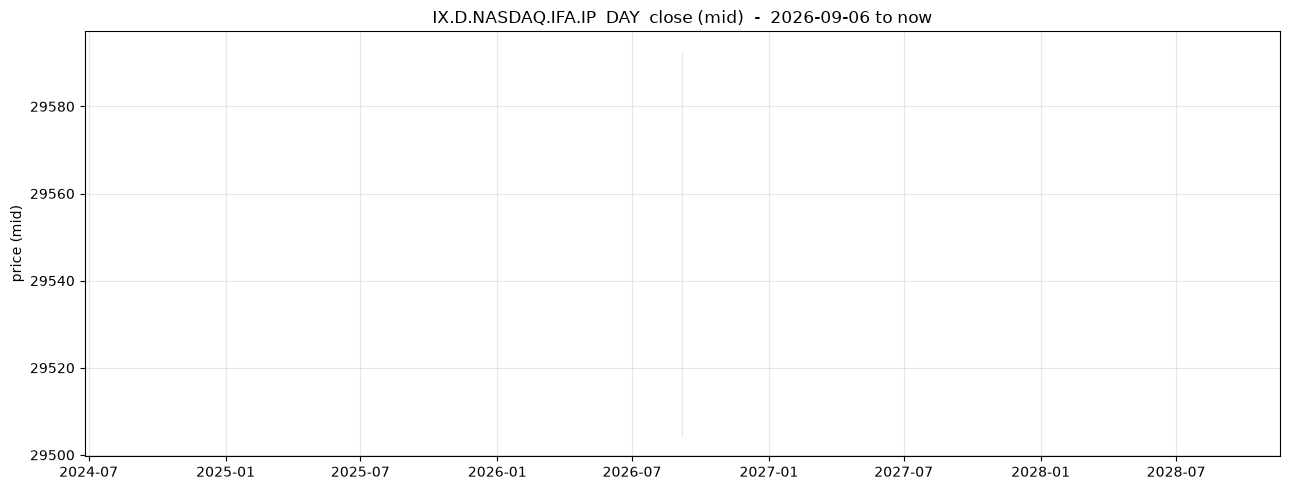

In [7]:
if df is None:
    print("Run the pandas cell above first.")
elif df.empty:
    print(
        f"No {RESOLUTION} candles between {START} and {END or 'now'} - "
        f"nothing to plot (e.g. a weekend / market-closed window); widen START/END."
    )
else:
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("matplotlib not installed - run:  %pip install matplotlib")
    else:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(df.index, df["close_mid_price"], color="#26a69a")
        ax.fill_between(df.index, df["low_mid_price"], df["high_mid_price"], color="#26a69a", alpha=0.15)
        ax.set_title(f"{cfg.epic}  {RESOLUTION}  close (mid)  -  {START} to {END or 'now'}")
        ax.set_ylabel("price (mid)")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()